# Late Fusion with Learnable Uncertainty Weighting for Water Detection (V2)

## 수정 사항 (V1 대비)
- **Loss**: Lovász only → **BCE + Lovász (0.5:0.5)**
- **LR**: 1e-4 → **5e-5**
- **Warmup**: 없음 → **3 epochs**
- **Gradient Clipping**: 없음 → **max_norm=1.0**
- **Weight Decay**: 없음 → **1e-4**

## 아키텍처
```
S2 (6ch) ──→ Optical Encoder ──┐
                               ├──→ Attention Fusion (각 level) ──→ Decoder ──→ Output
SAR (2ch) ──→ SAR Encoder ─────┘
                    ↑
            Cloud Probability (hint)
```

## 01. Imports & Setup

In [2]:
import os
import numpy as np
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings

# RuntimeWarning 무시 (DW 파일 NaN 관련)
warnings.filterwarnings('ignore', category=RuntimeWarning)

# GPU 확인
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


## 02. Dataset

In [3]:
class WaterDetectionDataset(Dataset):
    """
    Water Detection Dataset with Cloud Probability
    
    Returns:
        s2: (4, 6, H, W) - Sentinel-2 optical
        s1: (4, 2, H, W) - Sentinel-1 SAR
        cloud: (4, 1, H, W) - Cloud probability (0~1)
        gt: (4, H, W) - Water mask ground truth
    """
    def __init__(self, root_dir, split='train'):
        self.root_dir = root_dir
        self.split = split
        
        self.quarters = [
            [1, 2, 3],      # Q1
            [4, 5, 6],      # Q2
            [7, 8, 9],      # Q3
            [10, 11, 12]    # Q4
        ]
        
        split_path = f"{root_dir}/{split}"
        all_rois = sorted(os.listdir(split_path))
        
        self.samples = []
        
        for roi in all_rois:
            valid_months = []
            
            for q in self.quarters:
                found = False
                for month in q:
                    s2_dir = f'{root_dir}/{split}/{roi}/2022_{month}/s2_toa'
                    s1_dir = f'{root_dir}/{split}/{roi}/2022_{month}/s1'
                    dw_dir = f'{root_dir}/{split}/{roi}/2022_{month}/dw'
                    cld_dir = f'{root_dir}/{split}/{roi}/2022_{month}/cld_shdw'
                    
                    if (os.path.exists(s2_dir) and os.path.exists(s1_dir) and 
                        os.path.exists(dw_dir) and os.path.exists(cld_dir)):
                        if (len(os.listdir(s2_dir)) > 0 and len(os.listdir(s1_dir)) > 0 and 
                            len(os.listdir(dw_dir)) > 0 and len(os.listdir(cld_dir)) > 0):
                            valid_months.append(month)
                            found = True
                            break
                
                if not found:
                    valid_months = []
                    break
            
            if len(valid_months) == 4:
                self.samples.append({
                    'roi': roi,
                    'months': valid_months
                })
        
        print(f"[{split}] Valid samples: {len(self.samples)} / {len(all_rois)}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample_info = self.samples[idx]
        roi = sample_info['roi']
        months = sample_info['months']
        
        s2_list = []
        s1_list = []
        cld_list = []
        gt_list = []
        
        for month in months:
            # === S2 로드 + 정규화 ===
            s2_dir = f'{self.root_dir}/{self.split}/{roi}/2022_{month}/s2_toa'
            s2_file = sorted(os.listdir(s2_dir))[0]
            s2_path = os.path.join(s2_dir, s2_file)
            
            with rasterio.open(s2_path) as src:
                s2_data = src.read().astype(np.float32)
            
            bands = [1, 2, 3, 7, 11, 12]  # B, G, R, NIR, SWIR1, SWIR2
            s2_data = s2_data[bands]
            s2_data = np.nan_to_num(s2_data, nan=0)
            s2_data = np.where(s2_data == -9999, 0, s2_data)
            s2_data = s2_data / 10000.0
            s2_data = np.clip(s2_data, 0, 1)
            
            # === S1 로드 + 정규화 ===
            s1_dir = f'{self.root_dir}/{self.split}/{roi}/2022_{month}/s1'
            s1_file = sorted(os.listdir(s1_dir))[0]
            s1_path = os.path.join(s1_dir, s1_file)
            
            with rasterio.open(s1_path) as src:
                s1_data = src.read().astype(np.float32)
            
            s1_data = np.nan_to_num(s1_data, nan=0)
            s1_data = (s1_data + 35) / 40.0
            s1_data = np.clip(s1_data, 0, 1)
            
            # === Cloud Probability 로드 (Band 0) ===
            cld_dir = f'{self.root_dir}/{self.split}/{roi}/2022_{month}/cld_shdw'
            cld_file = sorted(os.listdir(cld_dir))[0]
            cld_path = os.path.join(cld_dir, cld_file)
            
            with rasterio.open(cld_path) as src:
                cld_data = src.read(1).astype(np.float32)  # Band 0 (1-indexed)
            
            cld_data = np.nan_to_num(cld_data, nan=0)
            cld_data = cld_data / 100.0  # 0~100 → 0~1
            cld_data = np.clip(cld_data, 0, 1)
            cld_data = cld_data[np.newaxis, ...]  # (1, H, W)
            
            # === DW 로드 + Water mask 변환 ===
            dw_dir = f'{self.root_dir}/{self.split}/{roi}/2022_{month}/dw'
            dw_file = sorted(os.listdir(dw_dir))[0]
            dw_path = os.path.join(dw_dir, dw_file)
            
            with rasterio.open(dw_path) as src:
                dw_data = src.read(1).astype(np.float32)  # float로 먼저 읽기
            
            dw_data = np.nan_to_num(dw_data, nan=255)
            dw_data = dw_data.astype(np.int64)
            water_mask = (dw_data == 0).astype(np.int64)
            
            s2_list.append(s2_data)
            s1_list.append(s1_data)
            cld_list.append(cld_data)
            gt_list.append(water_mask)
        
        s2_array = np.stack(s2_list, axis=0)    # (4, 6, H, W)
        s1_array = np.stack(s1_list, axis=0)    # (4, 2, H, W)
        cld_array = np.stack(cld_list, axis=0)  # (4, 1, H, W)
        gt_array = np.stack(gt_list, axis=0)    # (4, H, W)
        
        return {
            's2': s2_array,
            's1': s1_array,
            'cloud': cld_array,
            'gt': gt_array,
            'roi': roi,
            'months': months
        }

In [4]:
# 데이터셋 테스트
ROOT_DIR = '/home/beomsik/data_2_intern_students/beomsik/data/All_Clear/data'

dataset = WaterDetectionDataset(root_dir=ROOT_DIR, split='train')

sample = dataset[0]
print(f"S2 shape: {sample['s2'].shape}")      # (4, 6, 256, 256)
print(f"S1 shape: {sample['s1'].shape}")      # (4, 2, 256, 256)
print(f"Cloud shape: {sample['cloud'].shape}") # (4, 1, 256, 256)
print(f"GT shape: {sample['gt'].shape}")      # (4, 256, 256)
print(f"ROI: {sample['roi']}")
print(f"Months: {sample['months']}")
print(f"\nCloud prob range: [{sample['cloud'].min():.3f}, {sample['cloud'].max():.3f}]")
print(f"Water ratio: {sample['gt'].mean():.4f}")

[train] Valid samples: 3498 / 5000
S2 shape: (4, 6, 256, 256)
S1 shape: (4, 2, 256, 256)
Cloud shape: (4, 1, 256, 256)
GT shape: (4, 256, 256)
ROI: roi100315
Months: [1, 4, 7, 10]

Cloud prob range: [0.000, 1.000]
Water ratio: 0.0040


## 03. Model Components

In [5]:
class ConvBlock(nn.Module):
    """Conv → BN → ReLU → Conv → BN → ReLU"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)


class UNetEncoder(nn.Module):
    """UNet Encoder - returns multi-scale features"""
    def __init__(self, in_channels):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)
        self.enc4 = ConvBlock(256, 512)
        self.bottleneck = ConvBlock(512, 1024)
        self.pool = nn.MaxPool2d(2)
    
    def forward(self, x):
        e1 = self.enc1(x)                    # (B, 64, H, W)
        e2 = self.enc2(self.pool(e1))        # (B, 128, H/2, W/2)
        e3 = self.enc3(self.pool(e2))        # (B, 256, H/4, W/4)
        e4 = self.enc4(self.pool(e3))        # (B, 512, H/8, W/8)
        b = self.bottleneck(self.pool(e4))   # (B, 1024, H/16, W/16)
        
        return [e1, e2, e3, e4, b]

In [6]:
class AttentionFusion(nn.Module):
    """
    Learnable Attention Fusion Module
    
    Cloud probability를 힌트로 주되, 최종 weight는 attention으로 학습
    """
    def __init__(self, channels):
        super().__init__()
        # Input: opt_feat (C) + sar_feat (C) + cloud_prob (1) → attention weights (2)
        self.attention = nn.Sequential(
            nn.Conv2d(channels * 2 + 1, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels // 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // 2, 2, kernel_size=1),  # 2 weights: opt, sar
        )
        
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, opt_feat, sar_feat, cloud_prob):
        """
        Args:
            opt_feat: (B, C, H, W) - Optical encoder feature
            sar_feat: (B, C, H, W) - SAR encoder feature
            cloud_prob: (B, 1, H, W) - Cloud probability (0~1)
        
        Returns:
            fused: (B, C, H, W) - Fused feature
            weights: (B, 2, H, W) - Attention weights [w_opt, w_sar]
        """
        # Resize cloud_prob to match feature size
        if cloud_prob.shape[-2:] != opt_feat.shape[-2:]:
            cloud_prob = F.interpolate(cloud_prob, size=opt_feat.shape[-2:], 
                                       mode='bilinear', align_corners=False)
        
        # Concatenate all inputs
        # 채널 방향으로 합침
        combined = torch.cat([opt_feat, sar_feat, cloud_prob], dim=1)
        
        # Compute attention weights
        # 
        attn_logits = self.attention(combined)  # (B, 2, H, W)
        weights = self.softmax(attn_logits)     # (B, 2, H, W), sum=1
        
        w_opt = weights[:, 0:1, :, :]  # (B, 1, H, W)
        w_sar = weights[:, 1:2, :, :]  # (B, 1, H, W)
        
        # Weighted fusion
        fused = w_opt * opt_feat + w_sar * sar_feat
        
        return fused, weights

In [7]:
class UNetDecoder(nn.Module):
    """UNet Decoder with skip connections"""
    def __init__(self, num_classes=1):
        super().__init__()
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = ConvBlock(512 + 512, 512)
        
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ConvBlock(256 + 256, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(128 + 128, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ConvBlock(64 + 64, 64)
        
        self.out = nn.Conv2d(64, num_classes, 1)
    
    def forward(self, features):
        """
        Args:
            features: [f1, f2, f3, f4, fb] - fused features at each scale
        """
        f1, f2, f3, f4, fb = features
        
        d4 = self.dec4(torch.cat([self.up4(fb), f4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), f3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), f2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), f1], dim=1))
        
        out = self.out(d1)
        return out

## 04. Main Model: UNetLateFusion

In [8]:
class UNetLateFusion(nn.Module):
    """
    Late Fusion UNet with Learnable Uncertainty Weighting
    
    Architecture:
        - Dual Encoder: Optical (6ch) / SAR (2ch) 분리
        - Multi-scale Attention Fusion: Cloud Probability를 힌트로
        - Shared Decoder: 융합된 feature로 segmentation
    """
    def __init__(self, opt_channels=6, sar_channels=2, num_classes=1):
        super().__init__()
        
        # Dual Encoders
        self.opt_encoder = UNetEncoder(opt_channels)
        self.sar_encoder = UNetEncoder(sar_channels)
        
        # Multi-scale Attention Fusion
        self.fusion1 = AttentionFusion(64)
        self.fusion2 = AttentionFusion(128)
        self.fusion3 = AttentionFusion(256)
        self.fusion4 = AttentionFusion(512)
        self.fusion_b = AttentionFusion(1024)
        
        # Shared Decoder
        self.decoder = UNetDecoder(num_classes)
        
        # Default cloud value for inference without cloud input
        self.register_buffer('default_cloud', torch.tensor(0.5))
    
    def forward(self, s2, sar, cloud=None):
        """
        Args:
            s2: (B, T, 6, H, W) - Sentinel-2 optical
            sar: (B, T, 2, H, W) - Sentinel-1 SAR
            cloud: (B, T, 1, H, W) - Cloud probability (optional)
        
        Returns:
            out: (B, T, H, W) - Water segmentation logits
            attn_weights: dict of attention weights (for visualization)
        """
        B, T, C_opt, H, W = s2.shape
        
        # Handle missing cloud input
        if cloud is None:
            cloud = torch.full((B, T, 1, H, W), self.default_cloud.item(), 
                              device=s2.device, dtype=s2.dtype)
        
        # Reshape: (B, T, C, H, W) → (B*T, C, H, W)
        s2_flat = s2.view(B * T, C_opt, H, W)
        sar_flat = sar.view(B * T, sar.shape[2], H, W)
        cloud_flat = cloud.view(B * T, 1, H, W)
        
        # Dual Encoding
        opt_feats = self.opt_encoder(s2_flat)   # [e1, e2, e3, e4, b]
        sar_feats = self.sar_encoder(sar_flat)  # [s1, s2, s3, s4, sb]
        
        # Multi-scale Fusion
        f1, w1 = self.fusion1(opt_feats[0], sar_feats[0], cloud_flat)
        f2, w2 = self.fusion2(opt_feats[1], sar_feats[1], cloud_flat)
        f3, w3 = self.fusion3(opt_feats[2], sar_feats[2], cloud_flat)
        f4, w4 = self.fusion4(opt_feats[3], sar_feats[3], cloud_flat)
        fb, wb = self.fusion_b(opt_feats[4], sar_feats[4], cloud_flat)
        
        # Decode
        out = self.decoder([f1, f2, f3, f4, fb])  # (B*T, 1, H, W)
        
        # Reshape back: (B*T, 1, H, W) → (B, T, H, W)
        out = out.view(B, T, H, W)
        
        # Collect attention weights for visualization
        attn_weights = {
            'level1': w1.view(B, T, 2, w1.shape[-2], w1.shape[-1]),
            'level2': w2.view(B, T, 2, w2.shape[-2], w2.shape[-1]),
            'level3': w3.view(B, T, 2, w3.shape[-2], w3.shape[-1]),
            'level4': w4.view(B, T, 2, w4.shape[-2], w4.shape[-1]),
            'bottleneck': wb.view(B, T, 2, wb.shape[-2], wb.shape[-1]),
        }
        
        return out, attn_weights

In [9]:
# 모델 테스트
model = UNetLateFusion(opt_channels=6, sar_channels=2, num_classes=1)

# 가짜 입력
s2 = torch.randn(2, 4, 6, 256, 256)    # B=2, T=4시점, 6채널
sar = torch.randn(2, 4, 2, 256, 256)   # B=2, T=4시점, 2채널
cloud = torch.rand(2, 4, 1, 256, 256)  # B=2, T=4시점, 1채널 (0~1)

# Forward
out, attn_weights = model(s2, sar, cloud)
print(f"Output shape: {out.shape}")  # (2, 4, 256, 256)

# 파라미터 수
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Output shape: torch.Size([2, 4, 256, 256])
Total parameters: 81,351,147


## 05. Loss Function (BCE + Lovász)

In [10]:
def lovasz_grad(gt_sorted):
    """Lovász gradient 계산"""
    n = len(gt_sorted)
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1. - intersection / union
    if n > 1:
        jaccard[1:] = jaccard[1:] - jaccard[:-1]
    return jaccard


def lovasz_hinge_flat(logits, labels):
    """Binary Lovász Loss (flat 버전)"""
    if len(labels) == 0:
        return logits.sum() * 0.
    
    signs = 2. * labels.float() - 1.
    errors = 1. - logits * signs
    errors_sorted, perm = torch.sort(errors, dim=0, descending=True)
    perm = perm.data
    gt_sorted = labels[perm]
    grad = lovasz_grad(gt_sorted)
    loss = torch.dot(F.relu(errors_sorted), grad)
    return loss


class CombinedLoss(nn.Module):
    """
    BCE + Lovász Combined Loss
    
    BCE: 초기 학습 안정화
    Lovász: IoU 직접 최적화
    """
    def __init__(self, bce_weight=0.5, lovasz_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.lovasz_weight = lovasz_weight
    
    def forward(self, logits, labels):
        """
        Args:
            logits: (B, T, H, W) - sigmoid 전 raw output
            labels: (B, T, H, W) - GT (0 or 1)
        """
        # BCE Loss
        bce_loss = self.bce(logits, labels.float())
        
        # Lovász Loss
        logits_flat = logits.view(-1)
        labels_flat = labels.view(-1)
        lovasz_loss = lovasz_hinge_flat(logits_flat, labels_flat)
        
        # Combined
        total_loss = self.bce_weight * bce_loss + self.lovasz_weight * lovasz_loss
        
        return total_loss, bce_loss.item(), lovasz_loss.item()

## 06. Training (V2 - 안정화 버전)

In [11]:
def validate(model, loader, device):
    """Validation - Water IoU 계산"""
    model.eval()
    total_intersection = 0
    total_union = 0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc='Validation'):
            s2 = batch['s2'].float().to(device)
            sar = batch['s1'].float().to(device)
            cloud = batch['cloud'].float().to(device)
            gt = batch['gt'].to(device)
            
            logits, _ = model(s2, sar, cloud)
            pred = (torch.sigmoid(logits) > 0.5).long()
            
            intersection = ((pred == 1) & (gt == 1)).sum()
            union = ((pred == 1) | (gt == 1)).sum()
            
            total_intersection += intersection.item()
            total_union += union.item()
    
    iou = total_intersection / (total_union + 1e-8)
    return iou

In [12]:
def train_v2():
    """
    V2 학습 함수
    
    변경사항:
    - Loss: BCE + Lovász (0.5:0.5)
    - LR: 5e-5 (낮춤)
    - Warmup: 3 epochs
    - Gradient Clipping: max_norm=1.0
    - Weight Decay: 1e-4
    """
    # ===================
    # 1. Config
    # ===================
    config = {
        'root_dir': '/home/beomsik/data_2_intern_students/beomsik/data/All_Clear/data',
        'batch_size': 4,
        'lr': 5e-5,           # 낮춤 (기존 1e-4)
        'weight_decay': 1e-4, # 추가
        'epochs': 100,
        'warmup_epochs': 3,   # 추가
        'grad_clip': 1.0,     # 추가
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
        'save_dir': './checkpoints_v2'
    }
    
    os.makedirs(config['save_dir'], exist_ok=True)
    print(f"Device: {config['device']}")
    print(f"Config: {config}")
    
    # ===================
    # 2. Dataset & DataLoader
    # ===================
    train_dataset = WaterDetectionDataset(config['root_dir'], split='train')
    val_dataset = WaterDetectionDataset(config['root_dir'], split='val')
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    # ===================
    # 3. Model & Loss & Optimizer
    # ===================
    model = UNetLateFusion(opt_channels=6, sar_channels=2, num_classes=1)
    model = model.to(config['device'])
    
    # Combined Loss (BCE + Lovász)
    criterion = CombinedLoss(bce_weight=0.5, lovasz_weight=0.5)
    
    # Optimizer with weight decay
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=config['lr'],
        weight_decay=config['weight_decay']
    )
    
    # Print model info
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    
    # ===================
    # 4. Training Loop
    # ===================
    best_iou = 0
    history = {
        'train_loss': [], 'bce_loss': [], 'lovasz_loss': [],
        'val_iou': [], 'lr': []
    }
    
    for epoch in range(config['epochs']):
        # --- Learning Rate Schedule (Warmup + Cosine) ---
        if epoch < config['warmup_epochs']:
            # Linear warmup
            lr = config['lr'] * (epoch + 1) / config['warmup_epochs']
        else:
            # Cosine decay after warmup
            progress = (epoch - config['warmup_epochs']) / (config['epochs'] - config['warmup_epochs'])
            lr = config['lr'] * 0.5 * (1 + np.cos(np.pi * progress))
        
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
        
        history['lr'].append(lr)
        
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{config['epochs']} | LR: {lr:.2e}")
        print(f"{'='*60}")
        
        # --- Train ---
        model.train()
        train_loss = 0
        train_bce = 0
        train_lovasz = 0
        
        for batch in tqdm(train_loader, desc='Training'):
            optimizer.zero_grad()
            
            s2 = batch['s2'].float().to(config['device'])
            sar = batch['s1'].float().to(config['device'])
            cloud = batch['cloud'].float().to(config['device'])
            gt = batch['gt'].to(config['device'])
            
            logits, _ = model(s2, sar, cloud)
            loss, bce, lovasz = criterion(logits, gt)
            
            loss.backward()
            
            # Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config['grad_clip'])
            
            optimizer.step()
            
            train_loss += loss.item()
            train_bce += bce
            train_lovasz += lovasz
        
        train_loss /= len(train_loader)
        train_bce /= len(train_loader)
        train_lovasz /= len(train_loader)
        
        history['train_loss'].append(train_loss)
        history['bce_loss'].append(train_bce)
        history['lovasz_loss'].append(train_lovasz)
        
        print(f"Train Loss: {train_loss:.4f} (BCE: {train_bce:.4f}, Lovász: {train_lovasz:.4f})")
        
        # --- Validation ---
        val_iou = validate(model, val_loader, config['device'])
        history['val_iou'].append(val_iou)
        print(f"Val Water IoU: {val_iou:.4f}")
        
        # --- Save Best ---
        if val_iou > best_iou:
            best_iou = val_iou
            save_path = os.path.join(config['save_dir'], 'best_late_fusion_v2.pt')
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_iou': best_iou,
                'config': config,
                'history': history
            }, save_path)
            print(f"✅ Best model saved! IoU: {best_iou:.4f}")
        
        # --- Save checkpoint every 10 epochs ---
        if (epoch + 1) % 10 == 0:
            save_path = os.path.join(config['save_dir'], f'checkpoint_epoch{epoch+1}.pt')
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_iou': val_iou,
                'config': config,
                'history': history
            }, save_path)
            print(f"📁 Checkpoint saved at epoch {epoch+1}")
    
    print(f"\n{'='*60}")
    print(f"Training Complete! Best IoU: {best_iou:.4f}")
    print(f"{'='*60}")
    
    return model, history

In [13]:
# 학습 실행
model, history = train_v2()

Device: cuda
Config: {'root_dir': '/home/beomsik/data_2_intern_students/beomsik/data/All_Clear/data', 'batch_size': 4, 'lr': 5e-05, 'weight_decay': 0.0001, 'epochs': 100, 'warmup_epochs': 3, 'grad_clip': 1.0, 'device': 'cuda', 'save_dir': './checkpoints_v2'}
[train] Valid samples: 3498 / 5000
[val] Valid samples: 718 / 997
Total parameters: 81,351,147

Epoch 1/100 | LR: 1.67e-05


Training: 100%|████████████████████████████████████████████████████████████████████████| 875/875 [31:18<00:00,  2.15s/it]


Train Loss: 0.8190 (BCE: 0.5177, Lovász: 1.1204)


Validation: 100%|██████████████████████████████████████████████████████████████████████| 180/180 [03:00<00:00,  1.01s/it]


Val Water IoU: 0.4925
✅ Best model saved! IoU: 0.4925

Epoch 2/100 | LR: 3.33e-05


...

Val Water IoU: 0.5153

Epoch 100/100 | LR: 1.31e-08


Training: 100%|████████████████████████████████████████████████████████████████████████| 875/875 [23:14<00:00,  1.59s/it]


Train Loss: 0.5622 (BCE: 0.1268, Lovász: 0.9975)


Validation: 100%|██████████████████████████████████████████████████████████████████████| 180/180 [06:02<00:00,  2.01s/it]


Val Water IoU: 0.5206
📁 Checkpoint saved at epoch 100

Training Complete! Best IoU: 0.5351


## 07. Visualization

In [14]:
def plot_training_history(history):
    """학습 히스토리 시각화"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Total Loss
    axes[0, 0].plot(history['train_loss'], 'b-', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Total Training Loss')
    axes[0, 0].grid(True, alpha=0.3)
    
    # BCE vs Lovász Loss
    axes[0, 1].plot(history['bce_loss'], 'g-', label='BCE', linewidth=2)
    axes[0, 1].plot(history['lovasz_loss'], 'r-', label='Lovász', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_title('BCE vs Lovász Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Validation IoU
    axes[1, 0].plot(history['val_iou'], 'purple', linewidth=2, marker='o', markersize=4)
    axes[1, 0].axhline(y=max(history['val_iou']), color='r', linestyle='--', alpha=0.7, 
                       label=f"Best: {max(history['val_iou']):.4f}")
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('IoU')
    axes[1, 0].set_title('Validation Water IoU')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Learning Rate
    axes[1, 1].plot(history['lr'], 'orange', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate Schedule (Warmup + Cosine)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history_v2.png', dpi=150, bbox_inches='tight')
    plt.show()

In [15]:
def visualize_sample(model, dataset, idx=0, device='cuda'):
    """
    샘플 시각화: 입력, 출력, Attention weights
    """
    model.eval()
    sample = dataset[idx]
    
    with torch.no_grad():
        s2 = torch.from_numpy(sample['s2']).float().unsqueeze(0).to(device)
        sar = torch.from_numpy(sample['s1']).float().unsqueeze(0).to(device)
        cloud = torch.from_numpy(sample['cloud']).float().unsqueeze(0).to(device)
        
        logits, attn_weights = model(s2, sar, cloud)
        pred = (torch.sigmoid(logits) > 0.5).cpu().numpy()
        prob = torch.sigmoid(logits).cpu().numpy()
    
    # 시점별 시각화
    fig, axes = plt.subplots(4, 7, figsize=(28, 16))
    
    for t in range(4):
        # RGB
        rgb = sample['s2'][t, [2,1,0]].transpose(1, 2, 0)
        rgb = np.clip(rgb * 2.5, 0, 1)
        axes[t, 0].imshow(rgb)
        axes[t, 0].set_title(f'T{t+1}: S2 RGB')
        axes[t, 0].axis('off')
        
        # SAR VV
        axes[t, 1].imshow(sample['s1'][t, 0], cmap='gray')
        axes[t, 1].set_title(f'T{t+1}: SAR VV')
        axes[t, 1].axis('off')
        
        # Cloud probability
        im = axes[t, 2].imshow(sample['cloud'][t, 0], cmap='Reds', vmin=0, vmax=1)
        axes[t, 2].set_title(f'T{t+1}: Cloud Prob')
        axes[t, 2].axis('off')
        plt.colorbar(im, ax=axes[t, 2], fraction=0.046)
        
        # Ground Truth
        axes[t, 3].imshow(sample['gt'][t], cmap='Blues')
        axes[t, 3].set_title(f'T{t+1}: GT Water')
        axes[t, 3].axis('off')
        
        # Prediction Probability
        im = axes[t, 4].imshow(prob[0, t], cmap='Blues', vmin=0, vmax=1)
        axes[t, 4].set_title(f'T{t+1}: Pred Prob')
        axes[t, 4].axis('off')
        plt.colorbar(im, ax=axes[t, 4], fraction=0.046)
        
        # Prediction Binary
        axes[t, 5].imshow(pred[0, t], cmap='Blues')
        axes[t, 5].set_title(f'T{t+1}: Prediction')
        axes[t, 5].axis('off')
        
        # SAR Attention Weight (Level 1)
        w_sar = attn_weights['level1'][0, t, 1].cpu().numpy()  # SAR weight
        im = axes[t, 6].imshow(w_sar, cmap='RdYlBu', vmin=0, vmax=1)
        axes[t, 6].set_title(f'T{t+1}: SAR Weight')
        axes[t, 6].axis('off')
        plt.colorbar(im, ax=axes[t, 6], fraction=0.046)
    
    plt.suptitle(f"ROI: {sample['roi']}, Months: {sample['months']}", fontsize=14)
    plt.tight_layout()
    plt.savefig('sample_visualization_v2.png', dpi=150, bbox_inches='tight')
    plt.show()

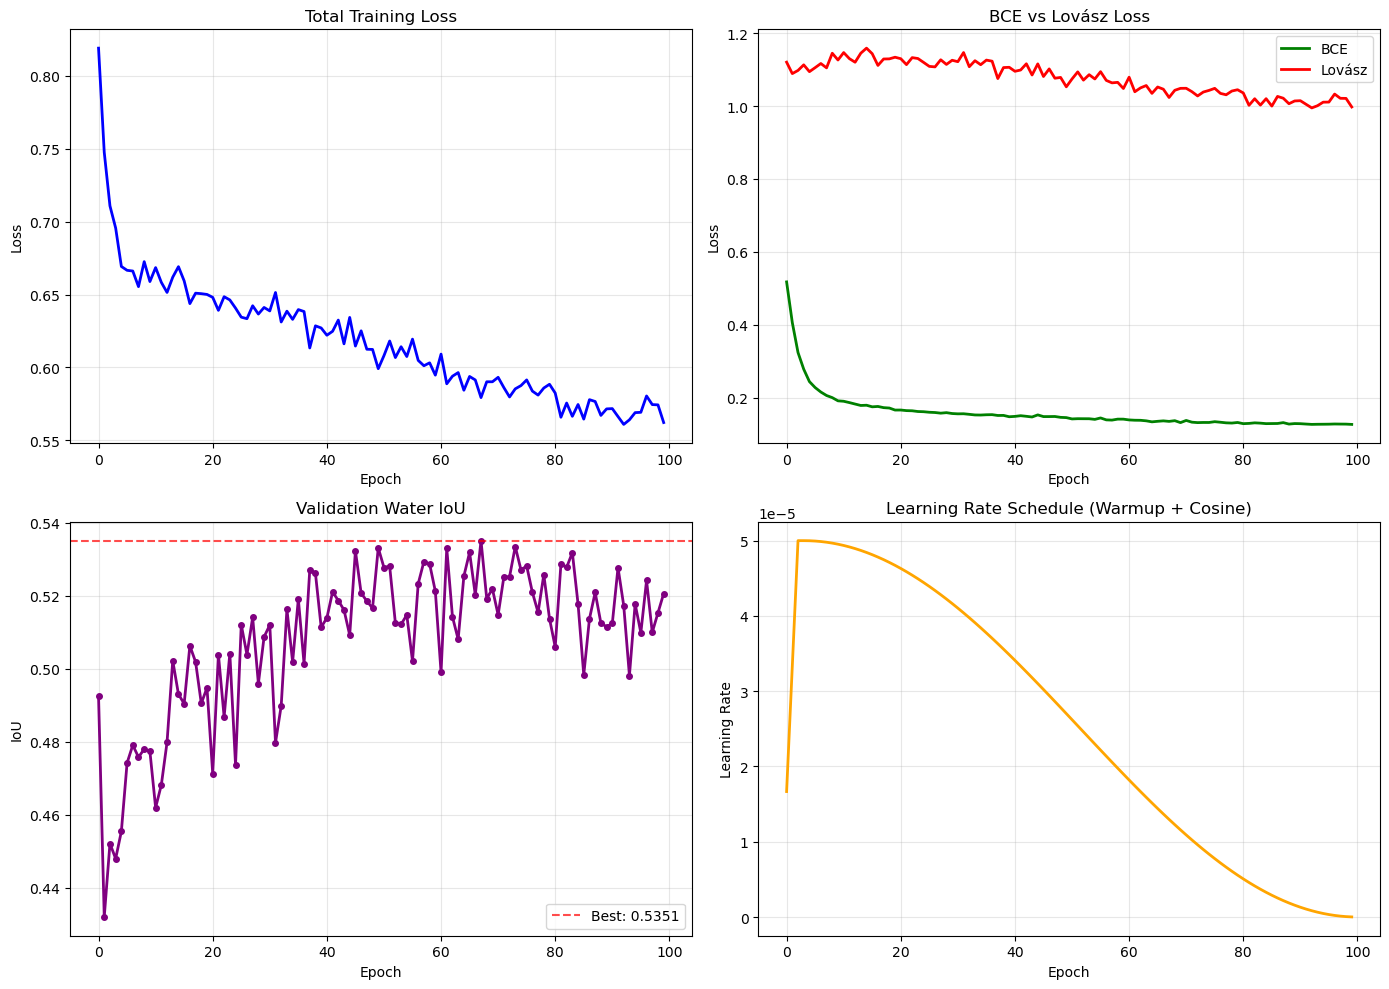

NameError: name 'val_dataset' is not defined

In [16]:
# 시각화 실행 (학습 후)
plot_training_history(history)
visualize_sample(model, val_dataset, idx=0, device=device)

In [ ]:
def visualize_attention_levels(model, dataset, idx=0, device='cuda'):
    """모든 레벨의 Attention weight 비교"""
    model.eval()
    sample = dataset[idx]
    
    with torch.no_grad():
        s2 = torch.from_numpy(sample['s2']).float().unsqueeze(0).to(device)
        sar = torch.from_numpy(sample['s1']).float().unsqueeze(0).to(device)
        cloud = torch.from_numpy(sample['cloud']).float().unsqueeze(0).to(device)
        
        _, attn_weights = model(s2, sar, cloud)
    
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    levels = ['level1', 'level2', 'level3', 'level4']
    
    for t in range(4):
        for lvl_idx, lvl in enumerate(levels):
            w_sar = attn_weights[lvl][0, t, 1].cpu().numpy()  # SAR weight
            im = axes[t, lvl_idx].imshow(w_sar, cmap='RdYlBu', vmin=0, vmax=1)
            axes[t, lvl_idx].set_title(f'T{t+1}: {lvl} SAR Weight')
            axes[t, lvl_idx].axis('off')
            plt.colorbar(im, ax=axes[t, lvl_idx], fraction=0.046)
    
    plt.suptitle(f"Multi-level Attention Weights (ROI: {sample['roi']})", fontsize=14)
    plt.tight_layout()
    plt.savefig('attention_levels_v2.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def visualize_cloud_attention_correlation(model, dataset, idx=0, device='cuda'):
    """Cloud probability와 SAR attention 간 관계 분석"""
    model.eval()
    sample = dataset[idx]
    
    with torch.no_grad():
        s2 = torch.from_numpy(sample['s2']).float().unsqueeze(0).to(device)
        sar = torch.from_numpy(sample['s1']).float().unsqueeze(0).to(device)
        cloud = torch.from_numpy(sample['cloud']).float().unsqueeze(0).to(device)
        
        _, attn_weights = model(s2, sar, cloud)
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    for t in range(4):
        cloud_prob = sample['cloud'][t, 0]
        w_sar = attn_weights['level1'][0, t, 1].cpu().numpy()
        
        # 위: 오버레이 시각화
        rgb = sample['s2'][t, [2,1,0]].transpose(1, 2, 0)
        rgb = np.clip(rgb * 2.5, 0, 1)
        axes[0, t].imshow(rgb)
        # SAR attention 높은 영역을 cyan으로
        mask = w_sar > 0.6
        overlay = np.zeros((*mask.shape, 4))
        overlay[mask] = [0, 1, 1, 0.5]  # cyan with alpha
        axes[0, t].imshow(overlay)
        axes[0, t].set_title(f'T{t+1}: RGB + High SAR Attn')
        axes[0, t].axis('off')
        
        # 아래: Scatter plot
        axes[1, t].scatter(cloud_prob.flatten(), w_sar.flatten(), alpha=0.1, s=1)
        axes[1, t].set_xlabel('Cloud Probability')
        axes[1, t].set_ylabel('SAR Attention')
        axes[1, t].set_title(f'T{t+1}: Correlation')
        axes[1, t].set_xlim(0, 1)
        axes[1, t].set_ylim(0, 1)
        # Correlation 계산
        corr = np.corrcoef(cloud_prob.flatten(), w_sar.flatten())[0, 1]
        axes[1, t].text(0.05, 0.95, f'r={corr:.3f}', transform=axes[1, t].transAxes, 
                        fontsize=12, verticalalignment='top')
    
    plt.suptitle(f"Cloud ↔ SAR Attention Correlation", fontsize=14)
    plt.tight_layout()
    plt.savefig('cloud_attention_correlation_v2.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def visualize_errors(model, dataset, idx=0, device='cuda'):
    """False Positive / False Negative 분석"""
    model.eval()
    sample = dataset[idx]
    
    with torch.no_grad():
        s2 = torch.from_numpy(sample['s2']).float().unsqueeze(0).to(device)
        sar = torch.from_numpy(sample['s1']).float().unsqueeze(0).to(device)
        cloud = torch.from_numpy(sample['cloud']).float().unsqueeze(0).to(device)
        
        logits, _ = model(s2, sar, cloud)
        pred = (torch.sigmoid(logits) > 0.5).cpu().numpy()[0]
    
    gt = sample['gt']
    
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    
    for t in range(4):
        # RGB
        rgb = sample['s2'][t, [2,1,0]].transpose(1, 2, 0)
        rgb = np.clip(rgb * 2.5, 0, 1)
        axes[t, 0].imshow(rgb)
        axes[t, 0].set_title(f'T{t+1}: RGB')
        axes[t, 0].axis('off')
        
        # GT
        axes[t, 1].imshow(gt[t], cmap='Blues')
        axes[t, 1].set_title(f'T{t+1}: GT')
        axes[t, 1].axis('off')
        
        # Prediction
        axes[t, 2].imshow(pred[t], cmap='Blues')
        axes[t, 2].set_title(f'T{t+1}: Pred')
        axes[t, 2].axis('off')
        
        # Error map: TP=Blue, FP=Red, FN=Yellow, TN=White
        error_map = np.zeros((*gt[t].shape, 3))
        tp = (gt[t] == 1) & (pred[t] == 1)
        fp = (gt[t] == 0) & (pred[t] == 1)
        fn = (gt[t] == 1) & (pred[t] == 0)
        tn = (gt[t] == 0) & (pred[t] == 0)
        
        error_map[tp] = [0, 0, 1]    # Blue: TP
        error_map[fp] = [1, 0, 0]    # Red: FP
        error_map[fn] = [1, 1, 0]    # Yellow: FN
        error_map[tn] = [0.9, 0.9, 0.9]  # Light gray: TN
        
        axes[t, 3].imshow(error_map)
        axes[t, 3].set_title(f'T{t+1}: TP(B)/FP(R)/FN(Y)')
        axes[t, 3].axis('off')
        
        # IoU 계산
        iou = tp.sum() / (tp.sum() + fp.sum() + fn.sum() + 1e-8)
        axes[t, 3].text(0.02, 0.98, f'IoU={iou:.3f}', transform=axes[t, 3].transAxes,
                        fontsize=10, verticalalignment='top', color='black',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.suptitle(f"Error Analysis (ROI: {sample['roi']})", fontsize=14)
    plt.tight_layout()
    plt.savefig('error_analysis_v2.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def visualize_temporal_consistency(model, dataset, idx=0, device='cuda'):
    """시점 간 예측 일관성 분석"""
    model.eval()
    sample = dataset[idx]
    
    with torch.no_grad():
        s2 = torch.from_numpy(sample['s2']).float().unsqueeze(0).to(device)
        sar = torch.from_numpy(sample['s1']).float().unsqueeze(0).to(device)
        cloud = torch.from_numpy(sample['cloud']).float().unsqueeze(0).to(device)
        
        logits, _ = model(s2, sar, cloud)
        prob = torch.sigmoid(logits).cpu().numpy()[0]
        pred = (prob > 0.5).astype(np.int32)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 시점 간 예측 변화
    pred_sum = pred.sum(axis=0)  # 몇 시점에서 water로 예측되었는지
    im = axes[0, 0].imshow(pred_sum, cmap='YlGnBu', vmin=0, vmax=4)
    axes[0, 0].set_title('Prediction Consistency\n(# of timesteps predicted as water)')
    axes[0, 0].axis('off')
    plt.colorbar(im, ax=axes[0, 0], fraction=0.046)
    
    # GT 변화
    gt_sum = sample['gt'].sum(axis=0)
    im = axes[0, 1].imshow(gt_sum, cmap='YlGnBu', vmin=0, vmax=4)
    axes[0, 1].set_title('GT Consistency\n(# of timesteps as water in GT)')
    axes[0, 1].axis('off')
    plt.colorbar(im, ax=axes[0, 1], fraction=0.046)
    
    # 일관성 차이
    diff = np.abs(pred_sum - gt_sum)
    im = axes[0, 2].imshow(diff, cmap='Reds', vmin=0, vmax=4)
    axes[0, 2].set_title('Temporal Inconsistency\n(|Pred - GT| across time)')
    axes[0, 2].axis('off')
    plt.colorbar(im, ax=axes[0, 2], fraction=0.046)
    
    # Probability variance across time
    prob_var = prob.var(axis=0)
    im = axes[1, 0].imshow(prob_var, cmap='hot', vmin=0, vmax=0.25)
    axes[1, 0].set_title('Probability Variance\n(uncertainty across time)')
    axes[1, 0].axis('off')
    plt.colorbar(im, ax=axes[1, 0], fraction=0.046)
    
    # Average probability
    prob_mean = prob.mean(axis=0)
    im = axes[1, 1].imshow(prob_mean, cmap='Blues', vmin=0, vmax=1)
    axes[1, 1].set_title('Mean Probability')
    axes[1, 1].axis('off')
    plt.colorbar(im, ax=axes[1, 1], fraction=0.046)
    
    # Cloud coverage per timestep (bar plot)
    cloud_coverage = [sample['cloud'][t, 0].mean() for t in range(4)]
    axes[1, 2].bar(['Q1', 'Q2', 'Q3', 'Q4'], cloud_coverage, color='gray', alpha=0.7)
    axes[1, 2].set_ylabel('Mean Cloud Prob')
    axes[1, 2].set_title('Cloud Coverage per Quarter')
    axes[1, 2].set_ylim(0, 1)
    
    plt.suptitle(f"Temporal Analysis (ROI: {sample['roi']})", fontsize=14)
    plt.tight_layout()
    plt.savefig('temporal_consistency_v2.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def visualize_batch_statistics(model, dataloader, device='cuda', num_batches=10):
    """여러 배치에 대한 통계 분석"""
    model.eval()
    
    all_ious = []
    all_cloud_means = []
    all_sar_attn_means = []
    
    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc='Computing stats', total=num_batches)):
            if i >= num_batches:
                break
            
            s2 = batch['s2'].to(device)
            sar = batch['s1'].to(device)
            cloud = batch['cloud'].to(device)
            gt = batch['gt'].to(device)
            
            logits, attn_weights = model(s2, sar, cloud)
            pred = (torch.sigmoid(logits) > 0.5).long()
            
            # Per-sample IoU
            for b in range(s2.size(0)):
                for t in range(4):
                    intersection = ((pred[b, t] == 1) & (gt[b, t] == 1)).sum().item()
                    union = ((pred[b, t] == 1) | (gt[b, t] == 1)).sum().item()
                    iou = intersection / (union + 1e-8)
                    
                    cloud_mean = cloud[b, t].mean().item()
                    sar_attn_mean = attn_weights['level1'][b, t, 1].mean().item()
                    
                    all_ious.append(iou)
                    all_cloud_means.append(cloud_mean)
                    all_sar_attn_means.append(sar_attn_mean)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # IoU distribution
    axes[0].hist(all_ious, bins=50, color='blue', alpha=0.7, edgecolor='black')
    axes[0].axvline(np.mean(all_ious), color='red', linestyle='--', label=f'Mean: {np.mean(all_ious):.3f}')
    axes[0].set_xlabel('Water IoU')
    axes[0].set_ylabel('Count')
    axes[0].set_title('IoU Distribution')
    axes[0].legend()
    
    # Cloud vs IoU
    axes[1].scatter(all_cloud_means, all_ious, alpha=0.3, s=10)
    axes[1].set_xlabel('Mean Cloud Probability')
    axes[1].set_ylabel('Water IoU')
    axes[1].set_title('Cloud Coverage vs Performance')
    # Trend line
    z = np.polyfit(all_cloud_means, all_ious, 1)
    p = np.poly1d(z)
    x_line = np.linspace(0, 1, 100)
    axes[1].plot(x_line, p(x_line), 'r--', alpha=0.8)
    
    # SAR attention vs Cloud
    axes[2].scatter(all_cloud_means, all_sar_attn_means, alpha=0.3, s=10)
    axes[2].set_xlabel('Mean Cloud Probability')
    axes[2].set_ylabel('Mean SAR Attention')
    axes[2].set_title('Cloud → SAR Attention')
    axes[2].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='y=x')
    axes[2].legend()
    
    plt.tight_layout()
    plt.savefig('batch_statistics_v2.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return {
        'ious': all_ious,
        'cloud_means': all_cloud_means,
        'sar_attn_means': all_sar_attn_means
    }

In [ ]:
# === 추가 시각화 실행 ===
# 데이터셋 로드 (train_v2 함수 밖에서 필요)
val_dataset = WaterDetectionDataset(config['root_dir'], split='val')

# 기본 시각화
plot_training_history(history)
visualize_sample(model, val_dataset, idx=0, device=device)

# 추가 분석
visualize_attention_levels(model, val_dataset, idx=0, device=device)
visualize_cloud_attention_correlation(model, val_dataset, idx=0, device=device)
visualize_errors(model, val_dataset, idx=0, device=device)
visualize_temporal_consistency(model, val_dataset, idx=0, device=device)

# 배치 통계 (시간이 좀 걸림)
# val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
# stats = visualize_batch_statistics(model, val_loader, device=device, num_batches=20)

## 08. Inference (복원 모델 연결용)

In [ ]:
def load_model(checkpoint_path, device='cuda'):
    """체크포인트에서 모델 로드"""
    model = UNetLateFusion(opt_channels=6, sar_channels=2, num_classes=1)
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    print(f"Loaded model from epoch {checkpoint['epoch']+1}")
    print(f"Best IoU: {checkpoint.get('best_iou', 'N/A')}")
    
    return model, checkpoint.get('history', None)


def predict(model, s2, sar, cloud=None, device='cuda'):
    """
    단일 샘플 예측
    
    Args:
        s2: (T, 6, H, W) or (B, T, 6, H, W) - numpy or tensor
        sar: (T, 2, H, W) or (B, T, 2, H, W)
        cloud: (T, 1, H, W) or (B, T, 1, H, W) - optional
    
    Returns:
        pred: binary water mask
        prob: probability
        attn_weights: dict
    """
    model.eval()
    
    # Convert to tensor if numpy
    if isinstance(s2, np.ndarray):
        s2 = torch.from_numpy(s2).float()
    if isinstance(sar, np.ndarray):
        sar = torch.from_numpy(sar).float()
    if cloud is not None and isinstance(cloud, np.ndarray):
        cloud = torch.from_numpy(cloud).float()
    
    # Add batch dimension if needed
    if s2.dim() == 4:
        s2 = s2.unsqueeze(0)
        sar = sar.unsqueeze(0)
        if cloud is not None:
            cloud = cloud.unsqueeze(0)
        squeeze_batch = True
    else:
        squeeze_batch = False
    
    s2 = s2.to(device)
    sar = sar.to(device)
    if cloud is not None:
        cloud = cloud.to(device)
    
    with torch.no_grad():
        logits, attn_weights = model(s2, sar, cloud)
        prob = torch.sigmoid(logits)
        pred = (prob > 0.5).long()
    
    # Remove batch dimension if added
    if squeeze_batch:
        pred = pred.squeeze(0)
        prob = prob.squeeze(0)
        attn_weights = {k: v.squeeze(0) for k, v in attn_weights.items()}
    
    return pred.cpu().numpy(), prob.cpu().numpy(), attn_weights

In [ ]:
# 사용 예시 (복원 모델 연결 시)
"""
# 1. 모델 로드
model, history = load_model('./checkpoints_v2/best_late_fusion_v2.pt')

# 2. 복원된 S2 + 실제 SAR로 예측 (cloud 없이)
restored_s2 = ...  # (4, 6, 256, 256) - 복원 모델 출력
real_sar = ...     # (4, 2, 256, 256) - 실제 SAR

pred, prob, attn = predict(model, restored_s2, real_sar, cloud=None)
print(f"Prediction shape: {pred.shape}")  # (4, 256, 256)
"""
print("Inference code ready!")

## 09. Summary

### V1 → V2 변경사항

| 항목 | V1 | V2 |
|------|-----|-----|
| **Loss** | Lovász only | BCE + Lovász (0.5:0.5) |
| **LR** | 1e-4 | 5e-5 |
| **Warmup** | 없음 | 3 epochs |
| **Grad Clip** | 없음 | max_norm=1.0 |
| **Weight Decay** | 없음 | 1e-4 |

### 예상 개선 효과
- BCE가 초기 학습 안정화
- Warmup으로 급격한 gradient 방지
- Gradient clipping으로 발산 방지
- Weight decay로 과적합 방지